### Import modules and optimization functions

In [1]:
from model.optimizer import optimizer
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

### Read data

In [2]:
hist_df = pd.read_pickle(r"input/historical_data.pkl")
hist_prices = pd.read_pickle(r"input/historical_prices.pkl")
fcst_df = pd.read_pickle(r"input/forecast_data.pkl")

bess_benchmark = pd.read_excel(r"raw_input/2hr_Wholesale_BESS_Index.xlsx", index_col=0)
bess_benchmark = bess_benchmark.iloc[:, 0].rename('revenue_benchmark') / 365 * 1000
# bess_benchmark.index = pd.to_datetime(bess_benchmark.index).tz_localize(tz="Europe/Berlin").rename("datetime")

### Define battery characteristics

In [7]:
energy_cap = 20
power_cap = 10
n_cycles = 2
cha_efficiency = 0.95
dis_efficiency = 0.95

optimizer_flex = optimizer(energy_cap=energy_cap, power_cap=power_cap, n_cycles=n_cycles, cha_efficiency=cha_efficiency, dis_efficiency=dis_efficiency)

### Compute historical revenues (€/MW) using optimization model

In [8]:
da_column = 'da_price'
idc_column = 'id1_price'


revenues = {}

for idc_day, idc_prices in hist_prices.groupby(hist_prices.index.date):
    if len(idc_prices) != 96:
        print(f"Skipping day {idc_day} because of insufficient data (only {len(idc_prices)} quarters).")
        continue

    daa_price_vector = idc_prices[da_column].tolist()
    idc_price_vector = idc_prices[idc_column].tolist()
    daa_revenue, idc_revenue = optimizer_flex.optimize(daa_price_vector=daa_price_vector, idc_price_vector=idc_price_vector)
    revenues[idc_day] = [daa_revenue, idc_revenue]

revenues = pd.DataFrame().from_dict(revenues, orient='index', columns=["DA_revenue", "IDC_revenue"])
revenues.index = pd.to_datetime(revenues.index)
revenues = (revenues / power_cap)


Skipping day 2025-01-01 because of insufficient data (only 92 quarters).
Skipping day 2025-03-30 because of insufficient data (only 92 quarters).
Skipping day 2025-10-01 because of insufficient data (only 101 quarters).
Skipping day 2025-10-26 because of insufficient data (only 108 quarters).
Skipping day 2026-03-14 because of insufficient data (only 4 quarters).


### Compare computed revenues (€/MW) with historical benchmark


Text(0.5, 1.0, 'Predicted hurdle rates (€/MW)')

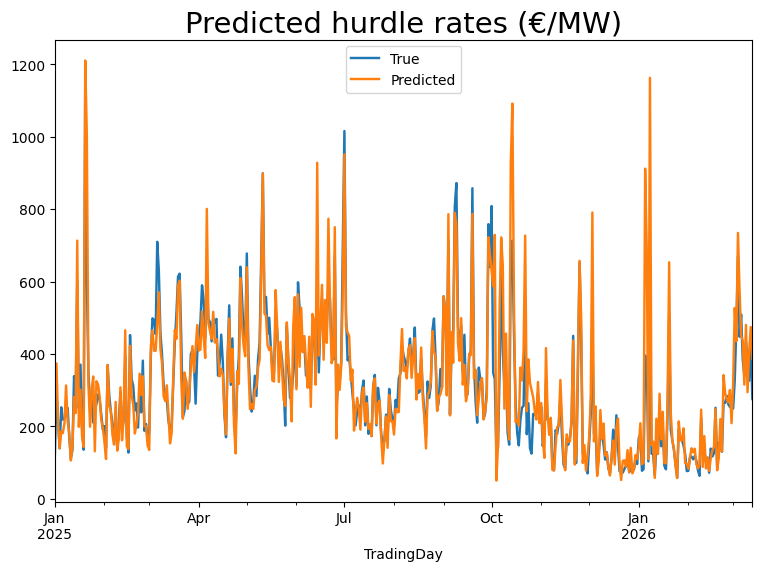

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
bess_benchmark.plot(ax=ax, legend=True, linewidth=1.75, label="True") 
revenues.sum(axis=1).plot(ax=ax, legend=True, linewidth=1.75, label="Predicted")
ax.set_title('Predicted hurdle rates (€/MW)', fontsize=21)

### Error metrics: Mean Absolute Error, Mean Deviation, Mean Squared Error, Mean Average Percentage Error

In [11]:
from IPython.display import display

def evaluate_results(df):

    eval_df = pd.Series()
    y_true = df["y_true"]
    y_pred = df["y_pred"]
    err = y_true - y_pred

    eval_df["No of pred."] = len(df)

    metrics =  {
    "MAE": np.abs(err),
    "MD": err,
    "MSE": err**2,
    "MAPE": np.abs(err / y_true) * 100,
}

    for met_name, metric in metrics.items(): 
        mean = np.mean(metric)
        std = np.std(metric)  
        eval_df[met_name] = f"{mean:.2f} ({std:.2f})"

    return eval_df


y_true = bess_benchmark.rename("y_true")
eval_dfs = []
for op in ('max', 'sum'):
    y_pred = getattr(revenues, op)(axis=1).rename("y_pred")
    df = y_pred.to_frame().join(y_true)
    eval_df = evaluate_results(df).rename(op)
    eval_dfs.append(eval_df)

eval_dfs = pd.concat(eval_dfs, axis=1)
display(eval_dfs)

,max,sum
No of pred.,433,433
MAE,70.97 (51.90),46.34 (66.47)
MD,64.08 (60.21),-10.55 (80.34)
MSE,7730.58 (11818.14),6566.14 (29428.44)
MAPE,24.34 (13.34),15.67 (17.58)


### Predict revenues for Mar 16th, 2026

In [13]:
from datetime import datetime, date

start_date = date(2026,3,1)
end_date = date(2026,3,28)

pred_revenues = []
pred_range = pd.date_range(start_date, end_date)

for daa_day in pred_range:
    print(f"Predicting day-ahead day {daa_day}...")
    day_revenues = {}
    for idc_day, idc_prices in hist_prices.groupby(hist_prices.index.date):
        if len(idc_prices) != 96:
            print(f"Skipping day {idc_day} because of insufficient data (only {len(idc_prices)} quarters).")
            continue

        daa_price_vector = fcst_df.loc[fcst_df.index.date == start_date, 'da_price'].tolist()
        daa_price_vector = np.repeat(daa_price_vector, 4)

        idc_price_vector = idc_prices[idc_column].tolist()
        daa_revenue, idc_revenue = optimizer_flex.optimize(daa_price_vector=daa_price_vector, idc_price_vector=idc_price_vector)
        day_revenues[idc_day] = [daa_revenue, idc_revenue]

    day_revenues = pd.DataFrame().from_dict(day_revenues, orient='index', columns=["DA_revenue", "IDC_revenue"])
    day_revenues.index = pd.to_datetime(day_revenues.index)
    day_revenues = (day_revenues / power_cap).sum(axis=1)
    pred_revenues.append(day_revenues)

pred_revenues = pd.concat(pred_revenues, axis=1)
pred_revenues.columns = pred_range

Predicting day-ahead day 2026-03-01 00:00:00...
Skipping day 2025-01-01 because of insufficient data (only 92 quarters).
Skipping day 2025-03-30 because of insufficient data (only 92 quarters).
Skipping day 2025-10-01 because of insufficient data (only 101 quarters).
Skipping day 2025-10-26 because of insufficient data (only 108 quarters).
Skipping day 2026-03-14 because of insufficient data (only 4 quarters).
Predicting day-ahead day 2026-03-02 00:00:00...
Skipping day 2025-01-01 because of insufficient data (only 92 quarters).
Skipping day 2025-03-30 because of insufficient data (only 92 quarters).
Skipping day 2025-10-01 because of insufficient data (only 101 quarters).
Skipping day 2025-10-26 because of insufficient data (only 108 quarters).
Skipping day 2026-03-14 because of insufficient data (only 4 quarters).
Predicting day-ahead day 2026-03-03 00:00:00...
Skipping day 2025-01-01 because of insufficient data (only 92 quarters).
Skipping day 2025-03-30 because of insufficient dat

### Visualize the distribution of predicted hurdle rates for Mar 16th, 2026

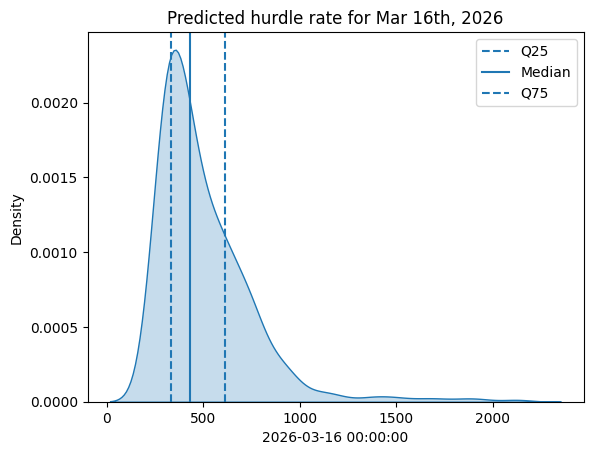

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

mar16_revenues = pred_revenues.iloc[:,15]
q25, q50, q75 = mar16_revenues.quantile([0.25, 0.5, 0.75]) 

# Plot KDE (vertical orientation so variable is on y-axis)
sns.kdeplot(x=mar16_revenues, fill=True)

# Add horizontal lines for quartiles
plt.axvline(q25, linestyle="--", label="Q25")
plt.axvline(q50, linestyle="-", label="Median")
plt.axvline(q75, linestyle="--", label="Q75")

plt.legend()
plt.title("Predicted hurdle rate for Mar 16th, 2026")
plt.show()

### Plot example optimal schedule for Mar 16th, 2026

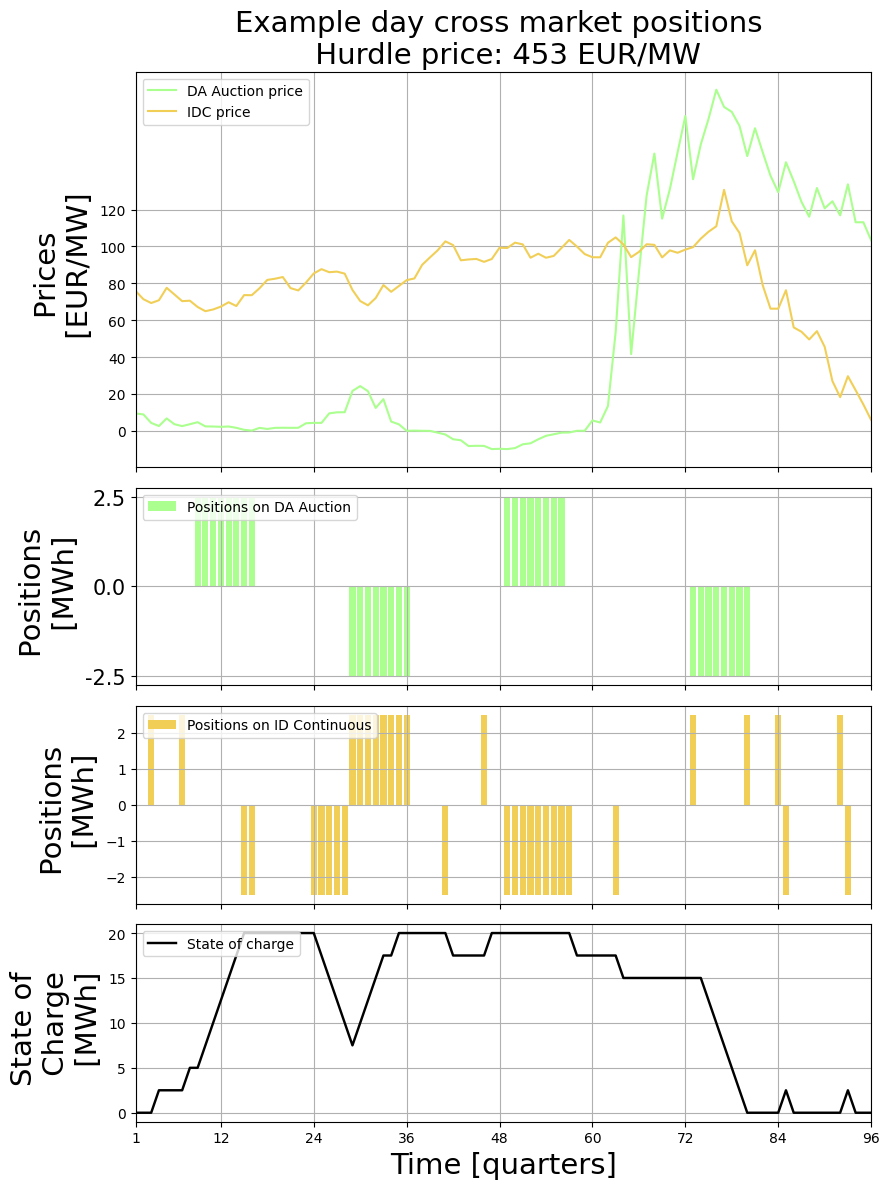

In [ ]:
color1 = (170/255,1,142/255,1)
color2 = (28/255,200/255,206/255,1)
color3 = (241/255,207/255,87/255,1)
    

random_day = pd.Timestamp(np.random.choice(revenues.index), tz=hist_prices.index.tz)
idc_price_vector = hist_prices.loc[hist_prices.index.floor("D") == random_day, idc_column].tolist()
_, step1_cha_daa, step1_dis_daa, _  = optimizer_flex.step1_optimize_daa(daa_price_vector=mar16_revenues)
step2_soc_idc, step2_cha_idc, step2_dis_idc, step2_cha_idc_close, step2_dis_idc_close, _, _, _ = optimizer_flex.step2_optimize_idc(idc_price_vector=idc_price_vector, step1_cha_daa=step1_cha_daa, step1_dis_daa=step1_dis_daa)
daa_revenue, idc_revenue = optimizer_flex.optimize(daa_price_vector=daa_price_vector, idc_price_vector=idc_price_vector)
revenue_total = (daa_revenue + idc_revenue) / power_cap

xgrid = np.arange(1, 97, 1)

fig, axs = plt.subplots(4, 1, figsize=(9, 12), gridspec_kw={'height_ratios': [2,1,1,1]}, sharex=True)

ax1, ax2, ax3, ax4 = axs

# Subplot 1
ax1.plot(xgrid, daa_price_vector, color=color1, label='DA Auction price')
ax1.plot(xgrid, idc_price_vector, color=color3, label='IDC price')
ax1.legend(loc="upper left")
ax1.grid()
ax1.set_xlim(1, len(idc_price_vector))
ax1.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax1.set_yticks([0,20,40,60,80,100,120])
ax1.set_ylabel('Prices \n [EUR/MW]', fontsize=21)
ax1.set_title(f'Example day cross market positions \n Hurdle price: {revenue_total:,.0f} EUR/MW', fontsize=21)


# Subplot 2

ax2.bar(xgrid, np.asarray(step1_cha_daa)*power_cap/4, color=color1, label='Positions on DA Auction', linewidth=1.75)
ax2.bar(xgrid, np.asarray(step1_dis_daa)*-power_cap/4, color=color1, linewidth=1.75)

ax2.legend(loc="upper left")
ax2.grid()
ax2.set_xlim(1, len(idc_price_vector))
ax2.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax2.set_ylim(-power_cap/4*1.1, power_cap/4*1.1)
ax2.set_yticks([-power_cap/4,0, power_cap/4])
ax2.set_yticklabels(ax2.get_yticks(), fontsize=15)
ax2.set_ylabel('Positions \n [MWh]', fontsize=21)


# Subplot 3
ax3.bar(xgrid, np.asarray(step2_cha_idc)*power_cap/4, color=color3, label='Positions on ID Continuous', linewidth=1.75)
ax3.bar(xgrid, np.asarray(step2_dis_idc)*-power_cap/4, color=color3, linewidth=1.75)
ax3.bar(xgrid, np.asarray(step2_cha_idc_close)*power_cap/4, color=color3, linewidth=1.75)
ax3.bar(xgrid, np.asarray(step2_dis_idc_close)*-power_cap/4, color=color3, linewidth=1.75)

ax3.legend(loc="upper left")
ax3.grid()
ax3.set_xlim(1, len(idc_price_vector))
ax3.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax3.set_ylabel('Positions \n [MWh]', fontsize=21)


# Subplot 5

ax4.plot(xgrid, step2_soc_idc, color='black', label='State of charge', linewidth=1.75)
ax4.legend(loc="upper left")
ax4.grid()
ax4.set_xlim(1, len(idc_price_vector))
ax4.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax4.set_xlabel('Time [quarters]', fontsize=21)
ax4.set_ylabel('State of \n Charge \n [MWh]', fontsize=21)

plt.tight_layout()
plt.show()
